# NB2 -- Analysis and Figures
## Loads from `Tables_datas/` -- no recomputation

**D. Sierra-Porta & Varotsos** (2025)

---
**Requires NB1_DataGenerator to have been run first.**

| Figure | Description |
|--------|-------------|
| Fig0 | Preprocessing diagnostic |
| Fig1 | Static MF-DFA: ATHN and JUNG (Varotsos replication) |
| Fig2 | Network summary bars |
| Fig3a/b | Rolling MF-DFA: ATHN and JUNG |
| Fig4a/b | Precursor Delta-alpha: Mar-2024 and May-2024 |
| Fig5 | Network heatmap h(2) and Delta-alpha |
| Fig6 | NTA-MF scatter (bridge figure) |
| Fig7 | Joint NTA+MF time series |
| Fig8 | Full time series with all 9 FD events |
| Fig9 | Superposed epoch analysis (SEA) |
| Fig10 | FD magnitude vs parameters scatter |


## 0. Setup, imports and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import spearmanr, binomtest
import os
import warnings
warnings.filterwarnings('ignore')

import scienceplots
import fathon
from fathon import fathonUtils as fu

plt.style.use(['science', 'nature'])
os.makedirs('Figures', exist_ok=True)

# ── Event dates ───────────────────────────────────────────────────────────────
FD1 = pd.Timestamp('2024-03-24')
FD2 = pd.Timestamp('2024-05-10')

FD_EVENTS = [
    {'date': pd.Timestamp('2011-10-24'), 'magnitude': 6.01},
    {'date': pd.Timestamp('2012-03-08'), 'magnitude': 10.40},
    {'date': pd.Timestamp('2012-07-14'), 'magnitude': 6.70},
    {'date': pd.Timestamp('2015-06-22'), 'magnitude': 8.57},
    {'date': pd.Timestamp('2017-09-07'), 'magnitude': 6.41},
    {'date': pd.Timestamp('2021-11-03'), 'magnitude': 9.68},
    {'date': pd.Timestamp('2023-04-23'), 'magnitude': 6.57},
    {'date': pd.Timestamp('2024-03-24'), 'magnitude': 11.47},
    {'date': pd.Timestamp('2024-05-10'), 'magnitude': 15.32},
]
df_fd = pd.DataFrame(FD_EVENTS).set_index('date')
fd_dates_list = df_fd.index.tolist()

print(f'fathon {fathon.__version__} ready.')
print(f'FD catalogue: {len(df_fd)} events')


fathon 1.3.3 ready.
FD catalogue: 9 events


In [2]:
# ── Load all Tables_datas ─────────────────────────────────────────────────────
df_static = pd.read_csv('Tables_datas/static_mfdfa.csv', index_col='station')
STATIONS        = df_static.index.tolist()
STABLE_STATIONS = df_static[df_static['q_stable']].index.tolist()

combined_ATHN = pd.read_csv('Tables_datas/combined_ATHN.csv',
                            index_col='date', parse_dates=True).dropna()
combined_JUNG = pd.read_csv('Tables_datas/combined_JUNG.csv',
                            index_col='date', parse_dates=True).dropna()

# Convenient aliases
roll_ATHN = combined_ATHN[['h2','delta_alpha']]
roll_JUNG = combined_JUNG[['h2','delta_alpha']]
nta_ATHN  = combined_ATHN[['kappa1','S_nta']]
nta_JUNG  = combined_JUNG[['kappa1','S_nta']]

# All stations rolling (for heatmap)
roll_all = {}
for fname in os.listdir('Tables_datas'):
    if fname.startswith('rolling_mfdfa_') and fname.endswith('.csv'):
        st = fname.replace('rolling_mfdfa_','').replace('.csv','')
        roll_all[st] = pd.read_csv(f'Tables_datas/{fname}',
                                   index_col='date', parse_dates=True)

df_fd_params = pd.read_csv('Tables_datas/fd_parameters.csv',
                           index_col='date', parse_dates=True)

# Raw data for preprocessing diagnostic and series plots
df_raw = pd.read_csv(
    'daily_mean_NMDBallstations_missing_lessthan5_2010-2025.csv',
    parse_dates=True)
df_raw['start_date_time'] = pd.to_datetime(df_raw['start_date_time'])
df_raw.set_index('start_date_time', inplace=True)
if 'MOSC' in df_raw.columns:
    df_raw = df_raw.drop(columns=['MOSC'])
df_clean = df_raw.interpolate(method='linear', limit=10).ffill().bfill()

print(f'Static    : {len(df_static)} stations | Stable: {len(STABLE_STATIONS)}')
print(f'ATHN combined: {len(combined_ATHN)} windows')
print(f'JUNG combined: {len(combined_JUNG)} windows')
print(f'Rolling all  : {len(roll_all)} stations')
print(f'FD params    : {len(df_fd_params)} events')


Static    : 16 stations | Stable: 16
ATHN combined: 5067 windows
JUNG combined: 5067 windows
Rolling all  : 16 stations
FD params    : 9 events


In [3]:
# Reconstruct normalised series for raw-series panels in figures
def preprocess_cr(df_in, clip_sigma=3.0, trend_window=365):
    df = df_in.copy()
    roll_med = df.rolling(30, center=True, min_periods=10).median()
    roll_std = df.rolling(30, center=True, min_periods=10).std()
    upper = roll_med + clip_sigma * roll_std
    lower = roll_med - clip_sigma * roll_std
    df_c = df.copy()
    for col in df.columns:
        mask = (df[col] > upper[col]) | (df[col] < lower[col])
        df_c.loc[mask, col] = np.nan
        df_c[col] = df_c[col].interpolate()
    trend = df_c.rolling(trend_window, center=True, min_periods=180).mean().ffill().bfill()
    df_detrend = df_c - trend
    return (df_detrend / df_c.mean() * 100), trend

df_norm, df_trend = preprocess_cr(df_clean)

# MF-DFA params needed for Fig1 (static spectrum plots)
WIN_SIZES_STATIC = fu.powRangeByCount(3, 10, 15, base=2)
QS      = np.arange(-5, 5.1, 0.25)
REV_SEG = True
POL_ORD = 2

print('Preprocessing done. Ready to plot.')


Preprocessing done. Ready to plot.


## Fig0 -- Preprocessing diagnostic

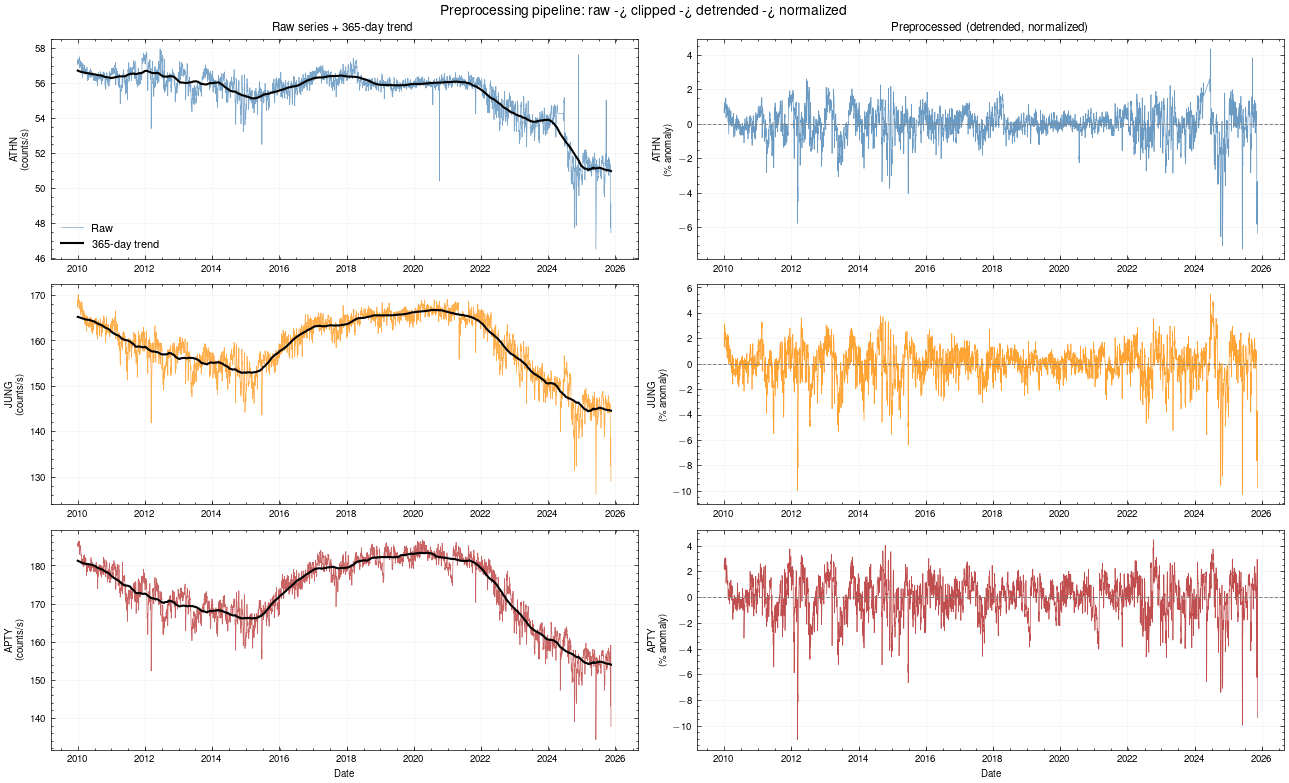

Saved: Figures/Fig0_Preprocessing_Diagnostic.pdf


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8))
check_stations = ['ATHN', 'JUNG', 'APTY']
colors_raw = ['steelblue', 'darkorange', 'firebrick']

for row, (st, col) in enumerate(zip(check_stations, colors_raw)):
    axes[row,0].plot(df_clean.index, df_clean[st], lw=0.5, color=col, alpha=0.7, label='Raw')
    axes[row,0].plot(df_trend.index, df_trend[st], lw=1.5, color='black', label='365-day trend')
    axes[row,0].set_ylabel(f'{st}\n(counts/s)')
    axes[row,0].grid(alpha=0.15)
    if row == 0:
        axes[row,0].set_title('Raw series + 365-day trend')
        axes[row,0].legend(fontsize=8)
    axes[row,1].plot(df_norm.index, df_norm[st], lw=0.5, color=col, alpha=0.8)
    axes[row,1].axhline(0, color='gray', ls='--', lw=0.7)
    axes[row,1].set_ylabel(f'{st}\n($\\%$ anomaly)')
    axes[row,1].grid(alpha=0.15)
    if row == 0:
        axes[row,1].set_title('Preprocessed (detrended, normalized)')

axes[2,0].set_xlabel('Date'); axes[2,1].set_xlabel('Date')
plt.suptitle('Preprocessing pipeline: raw -> clipped -> detrended -> normalized', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/Fig0_Preprocessing_Diagnostic.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig0_Preprocessing_Diagnostic.pdf')


## Fig1 -- Static MF-DFA: ATHN and JUNG (Varotsos replication)

ATHN: h2=1.027  da=1.296
JUNG: h2=0.988  da=0.452


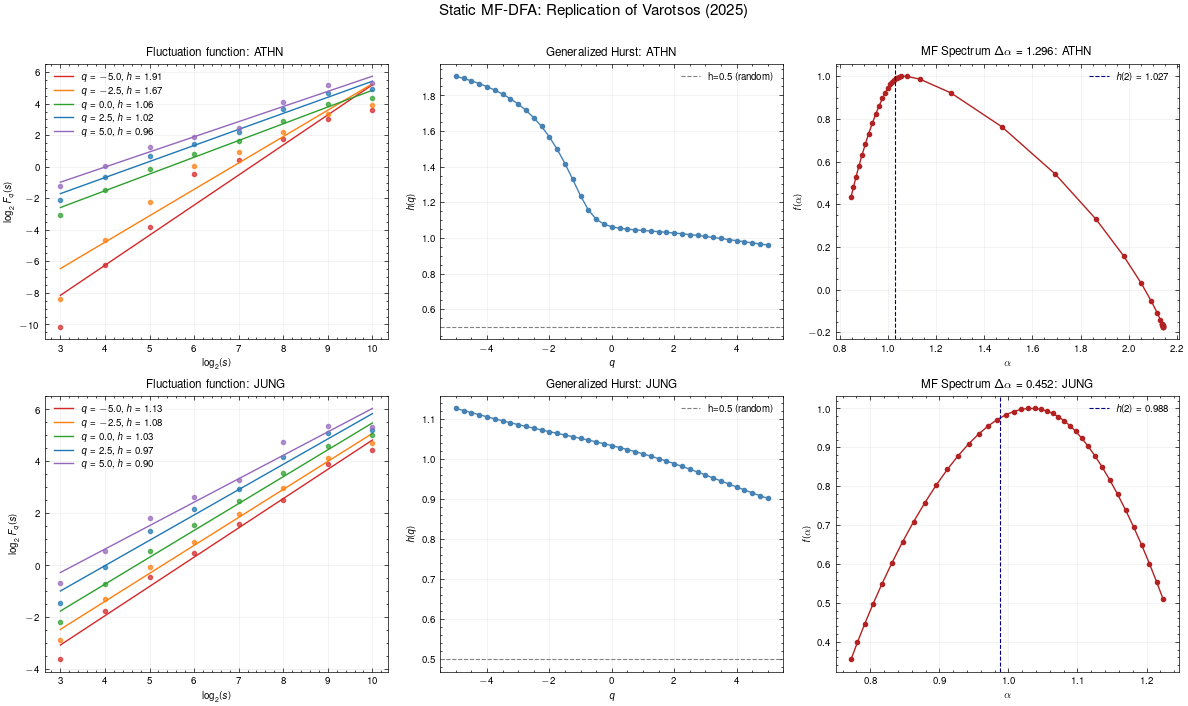

Saved: Figures/Fig1_StaticMFDFA_ATHN_JUNG.pdf


In [5]:
# Re-run static MF-DFA for ATHN and JUNG to get full spectrum objects
def run_mfdfa(series, win_sizes=WIN_SIZES_STATIC, qs=QS,
              rev_seg=REV_SEG, pol_ord=POL_ORD):
    x = fu.toAggregated(np.array(series, dtype=float))
    obj = fathon.MFDFA(x)
    n, F = obj.computeFlucVec(win_sizes, qs, revSeg=rev_seg, polOrd=pol_ord)
    list_H, list_H_intercept = obj.fitFlucVec()
    tau   = obj.computeMassExponents()
    alpha, f_alpha = obj.computeMultifractalSpectrum()
    h2 = list_H[np.argmin(np.abs(qs - 2))]
    valid = np.isfinite(alpha) & np.isfinite(f_alpha) & (f_alpha >= -0.5)
    delta_a = (alpha[valid].max() - alpha[valid].min() if valid.sum() >= 3 else np.nan)
    return {'n':n,'F':F,'qs':qs,'list_H':list_H,'list_H_intercept':list_H_intercept,
            'tau':tau,'alpha':alpha,'f_alpha':f_alpha,'h2':h2,'delta_alpha':delta_a}

res_ATHN = run_mfdfa(df_norm['ATHN'])
res_JUNG = run_mfdfa(df_norm['JUNG'])
print(f'ATHN: h2={res_ATHN["h2"]:.3f}  da={res_ATHN["delta_alpha"]:.3f}')
print(f'JUNG: h2={res_JUNG["h2"]:.3f}  da={res_JUNG["delta_alpha"]:.3f}')

def plot_mfdfa_summary(res, station_label, ax_fluc, ax_hurst, ax_spectrum):
    n, F, qs = res['n'], res['F'], res['qs']
    list_H, list_H_intercept = res['list_H'], res['list_H_intercept']
    alpha, f_alpha = res['alpha'], res['f_alpha']
    q_idx  = [0, len(qs)//4, len(qs)//2, 3*len(qs)//4, -1]
    colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
    for idx, col in zip(q_idx, colors):
        ax_fluc.plot(np.log2(n), np.log2(F[idx,:]), 'o', color=col, ms=3, alpha=0.7)
        ax_fluc.plot(np.log2(n),
                     list_H_intercept[idx]/np.log(2) + list_H[idx]*np.log2(n),
                     '-', color=col, label=f'$q={qs[idx]:.1f}$, $h={list_H[idx]:.2f}$')
    ax_fluc.set_xlabel(r'$\log_2(s)$'); ax_fluc.set_ylabel(r'$\log_2 F_q(s)$')
    ax_fluc.set_title(f'Fluctuation function: {station_label}')
    ax_fluc.legend(fontsize=7, loc='upper left'); ax_fluc.grid(alpha=0.2)
    ax_hurst.plot(qs, list_H, 'o-', color='steelblue', ms=3, lw=1)
    ax_hurst.axhline(0.5, color='gray', ls='--', lw=0.8, label='h=0.5 (random)')
    ax_hurst.set_xlabel('$q$'); ax_hurst.set_ylabel('$h(q)$')
    ax_hurst.set_title(f'Generalized Hurst: {station_label}')
    ax_hurst.legend(fontsize=7); ax_hurst.grid(alpha=0.2)
    ax_spectrum.plot(alpha, f_alpha, 'o-', color='firebrick', ms=3, lw=1)
    ax_spectrum.axvline(res['h2'], color='navy', ls='--', lw=0.8,
                        label=f'$h(2)={res["h2"]:.3f}$')
    ax_spectrum.set_xlabel(r'$\alpha$'); ax_spectrum.set_ylabel(r'$f(\alpha)$')
    ax_spectrum.set_title(f'MF Spectrum $\\Delta\\alpha={res["delta_alpha"]:.3f}$: {station_label}')
    ax_spectrum.legend(fontsize=7); ax_spectrum.grid(alpha=0.2)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
plot_mfdfa_summary(res_ATHN, 'ATHN', axes[0,0], axes[0,1], axes[0,2])
plot_mfdfa_summary(res_JUNG, 'JUNG', axes[1,0], axes[1,1], axes[1,2])
plt.suptitle('Static MF-DFA: Replication of Varotsos (2025)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('Figures/Fig1_StaticMFDFA_ATHN_JUNG.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig1_StaticMFDFA_ATHN_JUNG.pdf')


## Fig2 -- Network summary bars

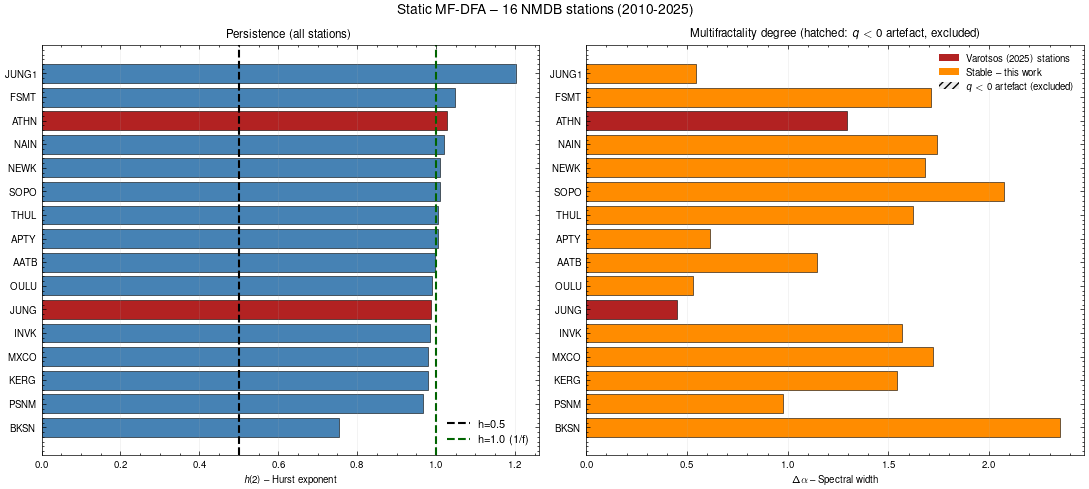

Saved: Figures/Fig2_StaticMFDFA_AllStations.pdf


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
sorted_idx = df_static['h2'].sort_values().index
h2_vals = df_static.loc[sorted_idx,'h2']
da_vals = df_static.loc[sorted_idx,'delta_alpha']

def bar_color_h2(s):
    return 'firebrick' if s in ['ATHN','JUNG'] else 'steelblue'
def bar_color_da(s):
    if s in ['ATHN','JUNG']: return 'firebrick'
    return 'darkorange' if s in STABLE_STATIONS else 'lightgray'

ax1.barh(sorted_idx, h2_vals, color=[bar_color_h2(s) for s in sorted_idx],
         edgecolor='k', lw=0.4)
ax1.axvline(0.5, color='k',   ls='--', lw=1.5, label='h=0.5')
ax1.axvline(1.0, color='darkgreen', ls='--', lw=1.5, label='h=1.0 (1/f)')
ax1.set_xlabel('$h(2)$ -- Hurst exponent')
ax1.set_title('Persistence (all stations)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.2, axis='x')

bars = ax2.barh(sorted_idx, da_vals.fillna(0),
                color=[bar_color_da(s) for s in sorted_idx],
                edgecolor='k', lw=0.4)
for bar, st in zip(bars, sorted_idx):
    if st not in STABLE_STATIONS:
        bar.set_hatch('////'); bar.set_alpha(0.4)
ax2.set_xlabel(r'$\Delta\alpha$ -- Spectral width')
ax2.set_title(r'Multifractality degree (hatched: $q<0$ artefact, excluded)')
legend_elements = [
    Patch(facecolor='firebrick',  label='Varotsos (2025) stations'),
    Patch(facecolor='darkorange', label='Stable -- this work'),
    Patch(facecolor='lightgray', hatch='////', alpha=0.4, label='$q<0$ artefact (excluded)'),
]
ax2.legend(handles=legend_elements, fontsize=7, loc='best')
ax2.grid(alpha=0.2, axis='x')
plt.suptitle('Static MF-DFA -- 16 NMDB stations (2010-2025)', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/Fig2_StaticMFDFA_AllStations.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig2_StaticMFDFA_AllStations.pdf')


## Fig3 -- Rolling MF-DFA: ATHN and JUNG

Saved: Figures/Fig3_RollingMFDFA_ATHN.pdf


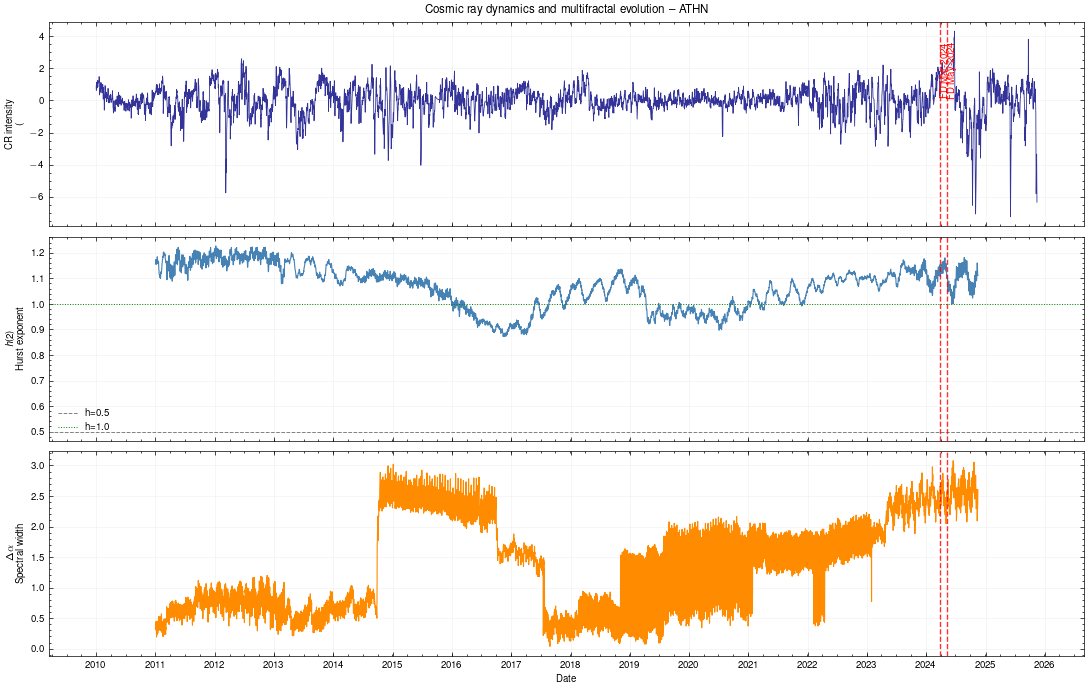

Saved: Figures/Fig3_RollingMFDFA_JUNG.pdf


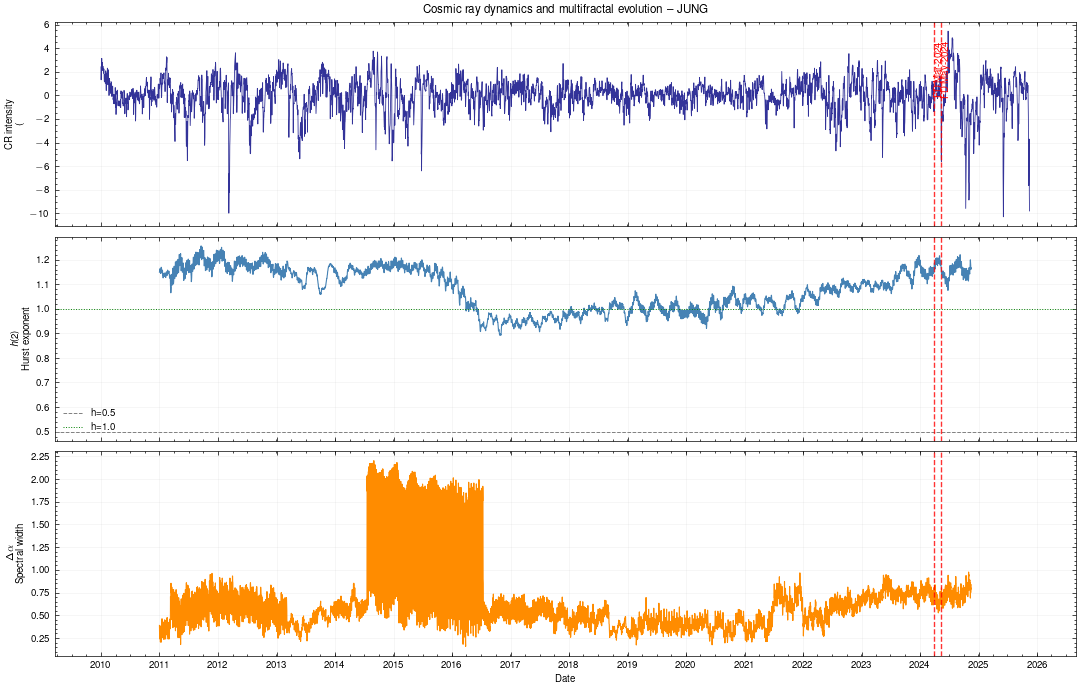

In [7]:
def plot_rolling_results(roll_df, raw_series, station_label, fd_dates=None, save=False):
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    fd_dates = fd_dates or []
    axes[0].plot(raw_series.index, raw_series.values, lw=0.6, color='navy', alpha=0.8)
    axes[0].set_ylabel('CR intensity\n(% anomaly)')
    axes[0].set_title(f'Cosmic ray dynamics and multifractal evolution -- {station_label}')
    axes[1].plot(roll_df.index, roll_df['h2'], lw=0.8, color='steelblue')
    axes[1].axhline(0.5, color='gray', ls='--', lw=0.7, label='h=0.5')
    axes[1].axhline(1.0, color='green', ls=':', lw=0.7, label='h=1.0')
    axes[1].set_ylabel('$h(2)$\nHurst exponent')
    axes[1].legend(fontsize=7, loc='lower left')
    axes[2].plot(roll_df.index, roll_df['delta_alpha'], lw=0.8, color='darkorange')
    axes[2].set_ylabel(r'$\Delta\alpha$' + '\nSpectral width')
    axes[2].set_xlabel('Date')
    fd_labels = ['FD Mar-2024', 'FD May-2024']
    for ax in axes:
        for fd, lbl in zip(fd_dates, fd_labels):
            ax.axvline(fd, color='red', ls='--', lw=1.0, alpha=0.8)
        ax.grid(alpha=0.15)
    for fd, lbl in zip(fd_dates, fd_labels):
        axes[0].annotate(lbl, xy=(fd, raw_series.max()*0.85),
                         fontsize=7, color='red', rotation=90, va='top')
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[2].xaxis.set_major_locator(mdates.YearLocator())
    plt.tight_layout()
    if save:
        plt.savefig(f'Figures/Fig3_RollingMFDFA_{station_label}.pdf',
                    dpi=300, bbox_inches='tight')
        print(f'Saved: Figures/Fig3_RollingMFDFA_{station_label}.pdf')
    plt.show()

plot_rolling_results(roll_ATHN, df_norm['ATHN'], 'ATHN', fd_dates=[FD1,FD2], save=True)
plot_rolling_results(roll_JUNG, df_norm['JUNG'], 'JUNG', fd_dates=[FD1,FD2], save=True)


## Fig4 -- Precursor Delta-alpha (ATHN and JUNG)

Saved: Figures/Fig4_Precursor_Dalpha_Mar2024.pdf


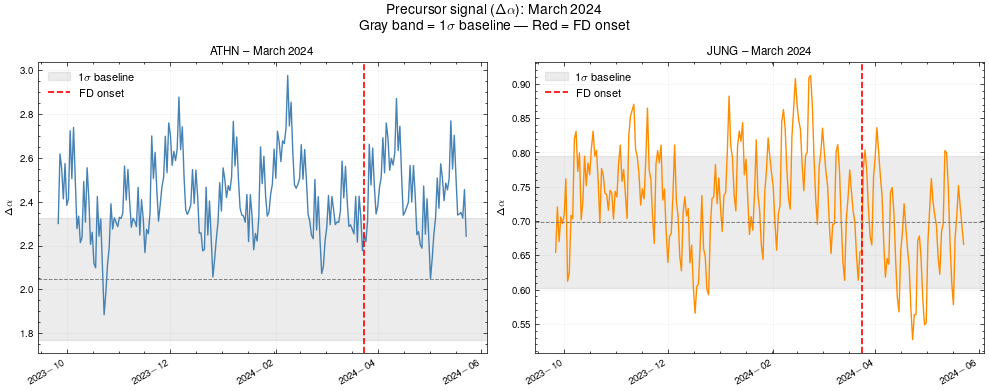

Saved: Figures/Fig4_Precursor_Dalpha_May2024.pdf


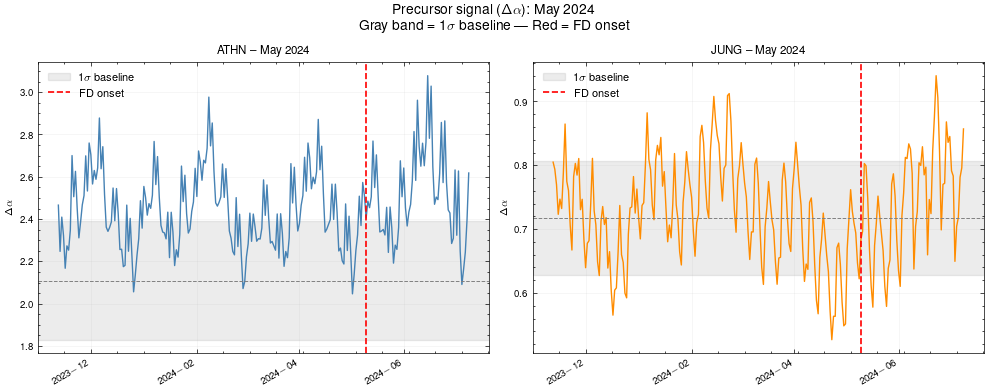

In [8]:
def plot_precursor_dalpha(roll_ATHN, roll_JUNG, fd_date, fd_label,
                          baseline_days=365, search_days=180, save_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    t_start  = fd_date - pd.Timedelta(days=search_days)
    t_end    = fd_date + pd.Timedelta(days=60)
    t_base_s = fd_date - pd.Timedelta(days=baseline_days + search_days)
    t_base_e = fd_date - pd.Timedelta(days=search_days)
    data = [('ATHN', roll_ATHN, 'steelblue'), ('JUNG', roll_JUNG, 'darkorange')]
    for ax, (st, roll_df, color) in zip(axes, data):
        seg  = roll_df.loc[t_start:t_end, 'delta_alpha'].dropna()
        base = roll_df.loc[t_base_s:t_base_e, 'delta_alpha'].dropna()
        mu, sig = base.mean(), base.std()
        ax.plot(seg.index, seg.values, lw=1.0, color=color)
        ax.axhspan(mu-sig, mu+sig, alpha=0.15, color='gray', label='$1\\sigma$ baseline')
        ax.axhline(mu, color='gray', ls='--', lw=0.7)
        ax.axvline(fd_date, color='red', ls='--', lw=1.2, label='FD onset')
        ax.set_ylabel(r'$\Delta\alpha$'); ax.set_title(f'{st} -- {fd_label}')
        ax.grid(alpha=0.15); ax.legend(fontsize=8, loc='upper left')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.suptitle(
        f'Precursor signal ($\\Delta\\alpha$): {fd_label}\n'
        f'Gray band = $1\\sigma$ baseline | Red = FD onset', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'Figures/Fig4_Precursor_Dalpha_{save_suffix}.pdf',
                dpi=300, bbox_inches='tight')
    print(f'Saved: Figures/Fig4_Precursor_Dalpha_{save_suffix}.pdf')
    plt.show()

plot_precursor_dalpha(roll_ATHN, roll_JUNG, FD1, 'March 2024', save_suffix='Mar2024')
plot_precursor_dalpha(roll_ATHN, roll_JUNG, FD2, 'May 2024',   save_suffix='May2024')


## Fig5 -- Network heatmap h(2) and Delta-alpha

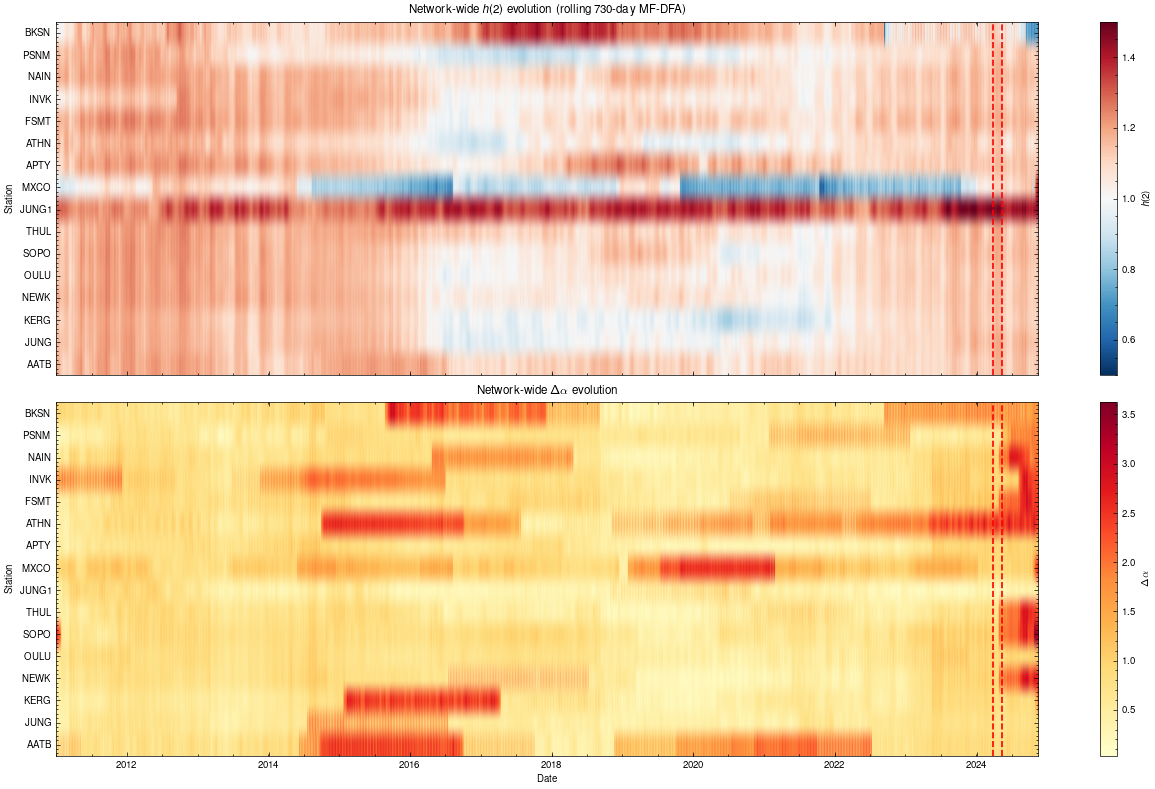

Saved: Figures/Fig5_NetworkHeatmap_h2_Dalpha.pdf


In [9]:
h2_matrix     = pd.DataFrame({st: roll_all[st]['h2']          for st in STATIONS if st in roll_all})
dalpha_matrix = pd.DataFrame({st: roll_all[st]['delta_alpha'] for st in STATIONS if st in roll_all})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

im1 = ax1.imshow(
    h2_matrix.T, aspect='auto', origin='lower', cmap='RdBu_r', vmin=0.5, vmax=1.5,
    extent=[mdates.date2num(h2_matrix.index[0]),
            mdates.date2num(h2_matrix.index[-1]),
            0, len(h2_matrix.columns)])
ax1.set_yticks(np.arange(len(h2_matrix.columns)) + 0.5)
ax1.set_yticklabels(h2_matrix.columns, fontsize=7)
ax1.xaxis_date(); ax1.set_ylabel('Station')
ax1.set_title('Network-wide $h(2)$ evolution (rolling 730-day MF-DFA)')
plt.colorbar(im1, ax=ax1, label='$h(2)$')

im2 = ax2.imshow(
    dalpha_matrix.T, aspect='auto', origin='lower', cmap='YlOrRd',
    extent=[mdates.date2num(dalpha_matrix.index[0]),
            mdates.date2num(dalpha_matrix.index[-1]),
            0, len(dalpha_matrix.columns)])
ax2.set_yticks(np.arange(len(dalpha_matrix.columns)) + 0.5)
ax2.set_yticklabels(dalpha_matrix.columns, fontsize=7)
ax2.xaxis_date(); ax2.set_ylabel('Station'); ax2.set_xlabel('Date')
ax2.set_title(r'Network-wide $\Delta\alpha$ evolution')
plt.colorbar(im2, ax=ax2, label=r'$\Delta\alpha$')

for ax in [ax1, ax2]:
    for fd in [FD1, FD2]:
        ax.axvline(mdates.date2num(fd), color='red', lw=1.2, ls='--')

plt.tight_layout()
plt.savefig('Figures/Fig5_NetworkHeatmap_h2_Dalpha.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig5_NetworkHeatmap_h2_Dalpha.pdf')


## Fig6 -- NTA-MF scatter (bridge figure)

kappa1 ~ h(2):  Pearson r=0.117 (p=8.52e-17) | Spearman rho=0.117
kappa1 ~ da:    Pearson r=0.043 (p=2.25e-03) | Spearman rho=0.043


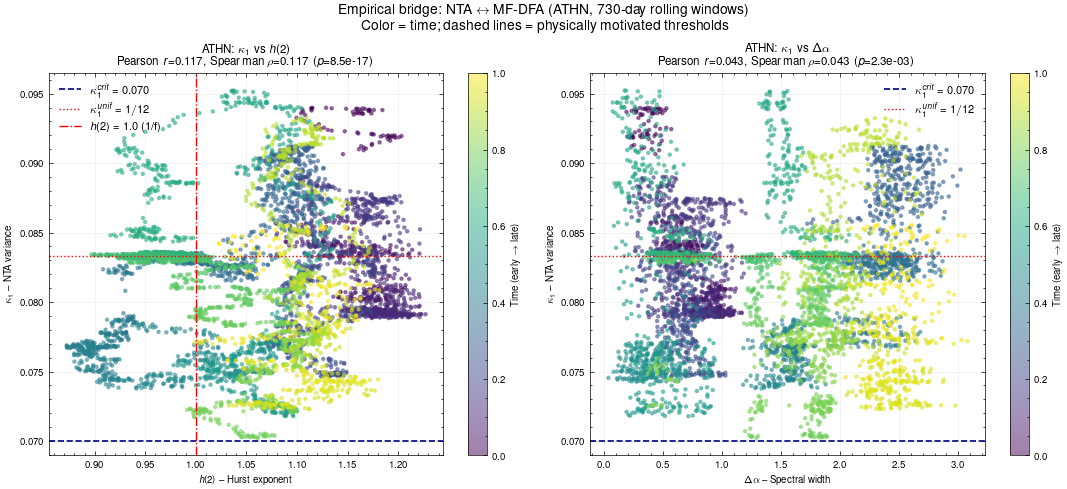

Saved: Figures/Fig6_NTA_MFDFA_Bridge_ATHN.pdf


In [10]:
r_p,  p_p  = stats.pearsonr( combined_ATHN['h2'],          combined_ATHN['kappa1'])
r_s,  _    = spearmanr(      combined_ATHN['h2'],          combined_ATHN['kappa1'])
r_p2, p_p2 = stats.pearsonr( combined_ATHN['delta_alpha'], combined_ATHN['kappa1'])
r_s2, _    = spearmanr(      combined_ATHN['delta_alpha'], combined_ATHN['kappa1'])

print(f'kappa1 ~ h(2):  Pearson r={r_p:.3f} (p={p_p:.2e}) | Spearman rho={r_s:.3f}')
print(f'kappa1 ~ da:    Pearson r={r_p2:.3f} (p={p_p2:.2e}) | Spearman rho={r_s2:.3f}')

colors_t = np.linspace(0, 1, len(combined_ATHN))
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sc1 = axes[0].scatter(combined_ATHN['h2'], combined_ATHN['kappa1'],
                      c=colors_t, cmap='viridis', s=5, alpha=0.5)
axes[0].axhline(0.070, color='navy',  ls='--', lw=1.2, label=r'$\kappa_1^{crit}=0.070$')
axes[0].axhline(1/12,  color='red',  ls=':',  lw=1.0, label=r'$\kappa_1^{unif}=1/12$')
axes[0].axvline(1.0,   color='red', ls='-.',  lw=1.0, label='$h(2)=1.0$ (1/f)')
axes[0].set_xlabel('$h(2)$ -- Hurst exponent')
axes[0].set_ylabel(r'$\kappa_1$ -- NTA variance')
axes[0].set_title(f'ATHN: $\\kappa_1$ vs $h(2)$\n'
                  f'Pearson $r$={r_p:.3f}, Spearman $\\rho$={r_s:.3f} ($p$={p_p:.1e})')
axes[0].legend(fontsize=8, loc='upper left'); axes[0].grid(alpha=0.2)
plt.colorbar(sc1, ax=axes[0], label='Time (early $\\rightarrow$ late)')

sc2 = axes[1].scatter(combined_ATHN['delta_alpha'], combined_ATHN['kappa1'],
                      c=colors_t, cmap='viridis', s=5, alpha=0.5)
axes[1].axhline(0.070, color='navy', ls='--', lw=1.2, label=r'$\kappa_1^{crit}=0.070$')
axes[1].axhline(1/12,  color='red', ls=':',  lw=1.0, label=r'$\kappa_1^{unif}=1/12$')
axes[1].set_xlabel(r'$\Delta\alpha$ -- Spectral width')
axes[1].set_ylabel(r'$\kappa_1$ -- NTA variance')
axes[1].set_title(f'ATHN: $\\kappa_1$ vs $\\Delta\\alpha$\n'
                  f'Pearson $r$={r_p2:.3f}, Spearman $\\rho$={r_s2:.3f} ($p$={p_p2:.1e})')
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(alpha=0.2)
plt.colorbar(sc2, ax=axes[1], label='Time (early $\\rightarrow$ late)')

plt.suptitle('Empirical bridge: NTA $\leftrightarrow$ MF-DFA (ATHN, 730-day rolling windows)\n'
             'Color = time; dashed lines = physically motivated thresholds', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/Fig6_NTA_MFDFA_Bridge_ATHN.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig6_NTA_MFDFA_Bridge_ATHN.pdf')


## Fig7 -- Joint NTA+MF time series (ATHN)

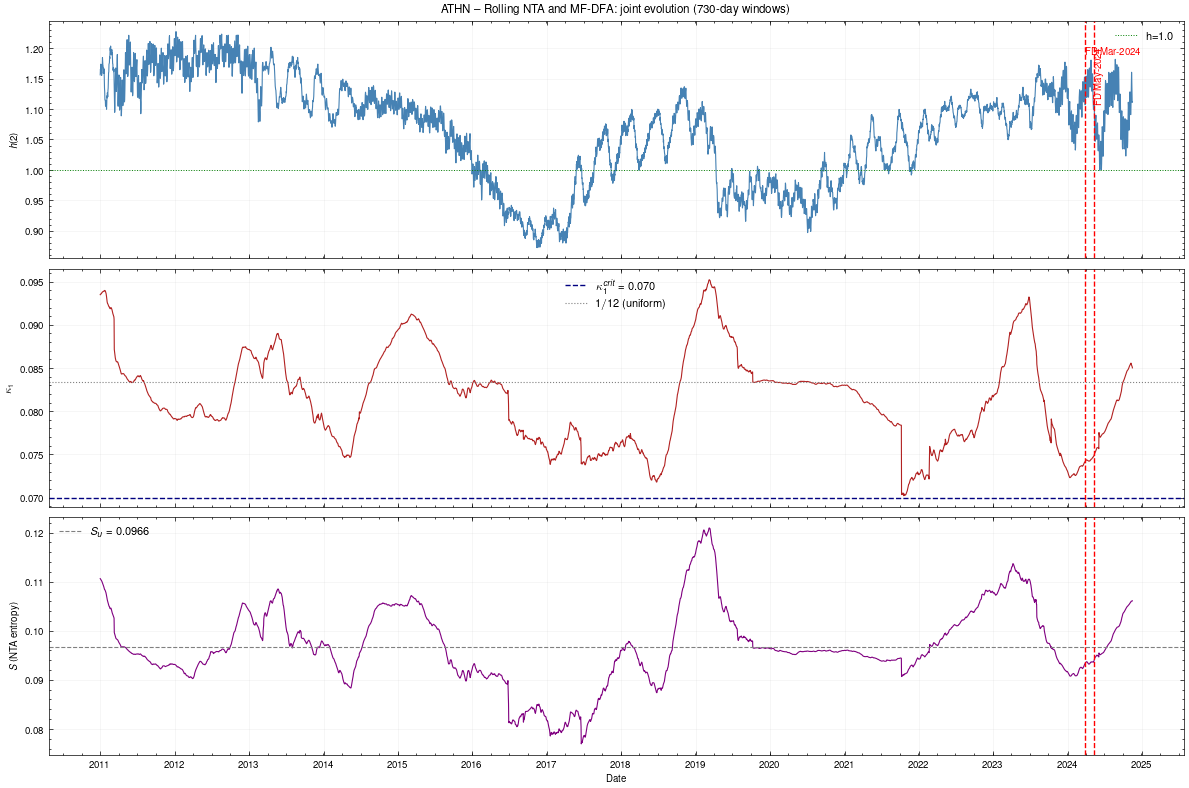

Saved: Figures/Fig7_JointNTA_MFDFA_TimeSeries.pdf


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(combined_ATHN.index, combined_ATHN['h2'], color='steelblue', lw=0.8)
axes[0].axhline(1.0, color='green', ls=':', lw=0.7, label='h=1.0')
axes[0].set_ylabel('$h(2)$'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.15)
axes[0].set_title('ATHN -- Rolling NTA and MF-DFA: joint evolution (730-day windows)')

axes[1].plot(combined_ATHN.index, combined_ATHN['kappa1'], color='firebrick', lw=0.8)
axes[1].axhline(0.070, color='navy', ls='--', lw=1.0, label=r'$\kappa_1^{crit}=0.070$')
axes[1].axhline(1/12,  color='gray', ls=':',  lw=0.8, label='$1/12$ (uniform)')
axes[1].set_ylabel(r'$\kappa_1$'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.15)

axes[2].plot(combined_ATHN.index, combined_ATHN['S_nta'], color='purple', lw=0.8)
axes[2].axhline(0.0966, color='gray', ls='--', lw=0.8, label='$S_u=0.0966$')
axes[2].set_ylabel('$S$ (NTA entropy)')
axes[2].set_xlabel('Date'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.15)

for ax in axes:
    ax.axvline(FD1, color='red', ls='--', lw=1.0)
    ax.axvline(FD2, color='red', ls='--', lw=1.0)

axes[0].annotate('FD Mar-2024', xy=(FD1, combined_ATHN['h2'].max()*0.98),
                 fontsize=7, color='red', rotation=0, ha="left",va='top')
axes[0].annotate('FD May-2024', xy=(FD2, combined_ATHN['h2'].max()*0.98),
                 fontsize=7, color='red', rotation=90, va='top')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig('Figures/Fig7_JointNTA_MFDFA_TimeSeries.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig7_JointNTA_MFDFA_TimeSeries.pdf')


## Fig8 -- Full time series with all 9 FD events

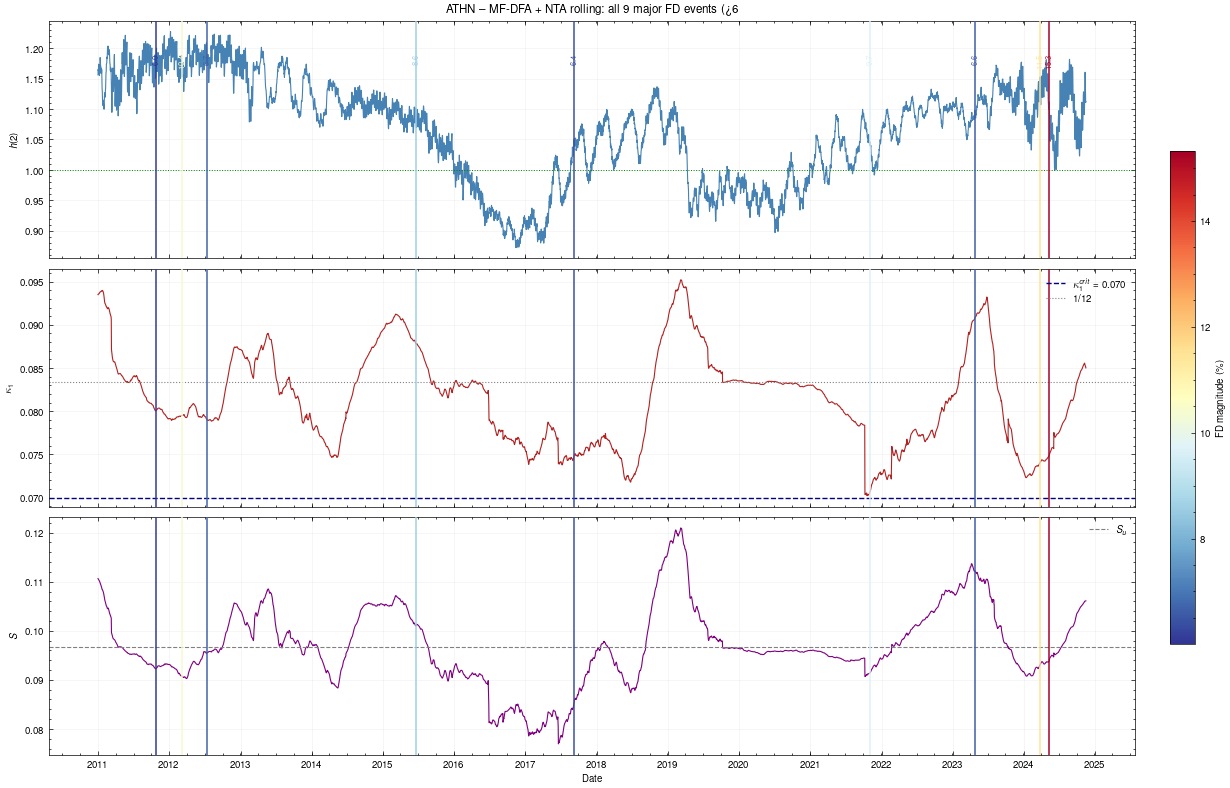

Saved: Figures/Fig8_AllFD_TimeSeries.pdf


In [12]:
mags   = df_fd['magnitude'].values
norm_c = mcolors.Normalize(vmin=mags.min(), vmax=mags.max())
cmap   = plt.cm.RdYlBu_r
fd_cols = [cmap(norm_c(m)) for m in mags]

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
axes[0].plot(combined_ATHN.index, combined_ATHN['h2'], color='steelblue', lw=0.8)
axes[0].axhline(1.0, color='green', ls=':', lw=0.7)
axes[0].set_ylabel('$h(2)$')
axes[0].set_title('ATHN -- MF-DFA + NTA rolling: all 9 major FD events (>6%, 2011-2024)')

axes[1].plot(combined_ATHN.index, combined_ATHN['kappa1'], color='firebrick', lw=0.8)
axes[1].axhline(0.070, color='navy', ls='--', lw=1.0, label=r'$\kappa_1^{crit}=0.070$')
axes[1].axhline(1/12,  color='gray', ls=':',  lw=0.8, label='1/12')
axes[1].set_ylabel(r'$\kappa_1$'); axes[1].legend(fontsize=7)

axes[2].plot(combined_ATHN.index, combined_ATHN['S_nta'], color='purple', lw=0.8)
axes[2].axhline(0.0966, color='gray', ls='--', lw=0.8, label='$S_u$')
axes[2].set_ylabel('$S$'); axes[2].set_xlabel('Date'); axes[2].legend(fontsize=7)

for ax in axes:
    ax.grid(alpha=0.15)
    for (fd_date, row), col in zip(df_fd.iterrows(), fd_cols):
        ax.axvline(fd_date, color=col, lw=1.2, alpha=0.9, zorder=5)

for (fd_date, row), col in zip(df_fd.iterrows(), fd_cols):
    axes[0].annotate(f"{row['magnitude']:.1f}%",
                     xy=(fd_date, combined_ATHN['h2'].max()*0.97),
                     fontsize=5.5, color=col, rotation=90, va='top', ha='center')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c); sm.set_array([])
fig.colorbar(sm, ax=axes, location='right', shrink=0.8,
             pad=-0.45, label='FD magnitude (\\%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig('Figures/Fig8_AllFD_TimeSeries.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig8_AllFD_TimeSeries.pdf')


## Fig9 -- Superposed Epoch Analysis (SEA)

In [13]:
HALF = 365
lags = np.arange(-HALF, HALF + 1)

def sea_matrix(series, fd_list, half=HALF):
    rows = []
    for fd in fd_list:
        seg = series.loc[fd - pd.Timedelta(days=half) : fd + pd.Timedelta(days=half)]
        if len(seg) < half: continue
        idx = pd.date_range(fd - pd.Timedelta(days=half),
                            fd + pd.Timedelta(days=half), freq='D')
        seg = seg.reindex(idx, method='nearest', tolerance='2D')
        if seg.isna().sum() > half * 0.1: continue
        rows.append(seg.values)
    return np.array(rows) if rows else np.empty((0, 2*half+1))

M_h2_athn = sea_matrix(combined_ATHN['h2'],          fd_dates_list)
M_k1_athn = sea_matrix(combined_ATHN['kappa1'],      fd_dates_list)
M_da_athn = sea_matrix(combined_ATHN['delta_alpha'], fd_dates_list)
M_h2_jung = sea_matrix(combined_JUNG['h2'],          fd_dates_list)
M_k1_jung = sea_matrix(combined_JUNG['kappa1'],      fd_dates_list)
M_da_jung = sea_matrix(combined_JUNG['delta_alpha'], fd_dates_list)

for nm, M in [('h2 ATHN',M_h2_athn),('k1 ATHN',M_k1_athn),
               ('da ATHN',M_da_athn),('h2 JUNG',M_h2_jung),
              ('k1 JUNG',M_k1_jung),('da JUNG',M_da_jung)]:
    print(f'{nm}: {M.shape[0]} events stacked')


h2 ATHN: 6 events stacked
k1 ATHN: 6 events stacked
da ATHN: 6 events stacked
h2 JUNG: 6 events stacked
k1 JUNG: 6 events stacked
da JUNG: 6 events stacked


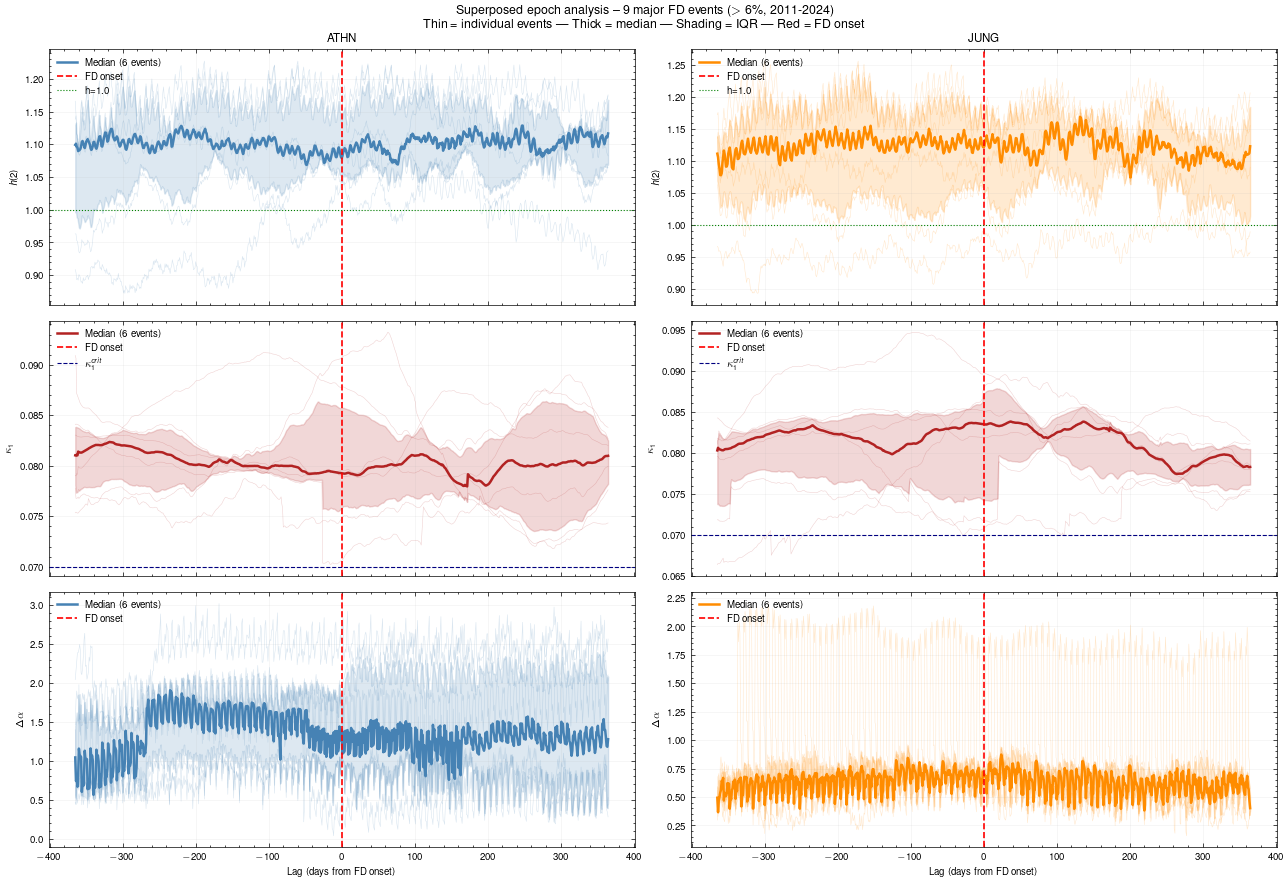

Saved: Figures/Fig9_SEA_MF_NTA.pdf


In [14]:
def plot_sea(ax, M, lags, color, ylabel, hline=None, hline_kw=None):
    if M.shape[0] == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes); return
    med = np.nanmedian(M, axis=0)
    q25 = np.nanpercentile(M, 25, axis=0)
    q75 = np.nanpercentile(M, 75, axis=0)
    for row in M:
        ax.plot(lags, row, lw=0.4, color=color, alpha=0.2)
    ax.fill_between(lags, q25, q75, color=color, alpha=0.18)
    ax.plot(lags, med, lw=1.8, color=color, label=f'Median ({M.shape[0]} events)')
    ax.axvline(0, color='red', ls='--', lw=1.2, label='FD onset')
    if hline is not None:
        ax.axhline(hline, **(hline_kw or {}))
    ax.set_ylabel(ylabel); ax.grid(alpha=0.15)
    ax.legend(fontsize=7, loc='upper left')

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
plot_sea(axes[0,0], M_h2_athn, lags, 'steelblue',  '$h(2)$',
         hline=1.0, hline_kw={'color':'green','ls':':','lw':0.8,'label':'h=1.0'})
axes[0,0].set_title('ATHN')
plot_sea(axes[0,1], M_h2_jung, lags, 'darkorange', '$h(2)$',
         hline=1.0, hline_kw={'color':'green','ls':':','lw':0.8,'label':'h=1.0'})
axes[0,1].set_title('JUNG')
plot_sea(axes[1,0], M_k1_athn, lags, 'firebrick', r'$\kappa_1$',
         hline=0.070, hline_kw={'color':'navy','ls':'--','lw':0.8,'label':r'$\kappa_1^{crit}$'})
plot_sea(axes[1,1], M_k1_jung, lags, 'firebrick', r'$\kappa_1$',
         hline=0.070, hline_kw={'color':'navy','ls':'--','lw':0.8,'label':r'$\kappa_1^{crit}$'})
#axes[1,1].axis('off')
plot_sea(axes[2,0], M_da_athn, lags, 'steelblue',  r'$\Delta\alpha$')
axes[2,0].set_xlabel('Lag (days from FD onset)')
plot_sea(axes[2,1], M_da_jung, lags, 'darkorange', r'$\Delta\alpha$')
axes[2,1].set_xlabel('Lag (days from FD onset)')
plt.suptitle(
    f'Superposed epoch analysis -- {len(fd_dates_list)} major FD events ($>6\\%$, 2011-2024)\n'
    'Thin = individual events | Thick = median | Shading = IQR | Red = FD onset',
    fontsize=9)
plt.tight_layout()
plt.savefig('Figures/Fig9_SEA_MF_NTA.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig9_SEA_MF_NTA.pdf')


## Fig10 -- Pattern check and FD magnitude scatter

Background (3670 windows): h2=1.0528  kappa1=0.0820  DeltaAlpha=1.3590

Date           Mag%      h2  h2>bg      k1    k1<bg DeltaAlpha    da<bg Both h2 and k1
----------------------------------------------------------------------------------------------------
2011-10-24     6.01  1.1548    YES  0.0800      YES     0.8926      YES YES                 
2012-03-08    10.40  1.1532    YES  0.0795      YES     1.0630      YES YES                 
2012-07-14     6.70  1.1714    YES  0.0790      YES     1.0680      YES YES                 
2015-06-22     8.57  1.0696    YES  0.0878       NO     2.7424       NO NO                  
2017-09-07     6.41  1.0486     NO  0.0748      YES     0.5215      YES NO                  
2021-11-03     9.68  1.0399     NO  0.0706      YES     1.7521       NO NO                  
2023-04-23     6.57  1.0884    YES  0.0907       NO     1.7329       NO NO                  
2024-03-24    11.47  1.1525    YES  0.0741      YES     2.2470       NO YES              

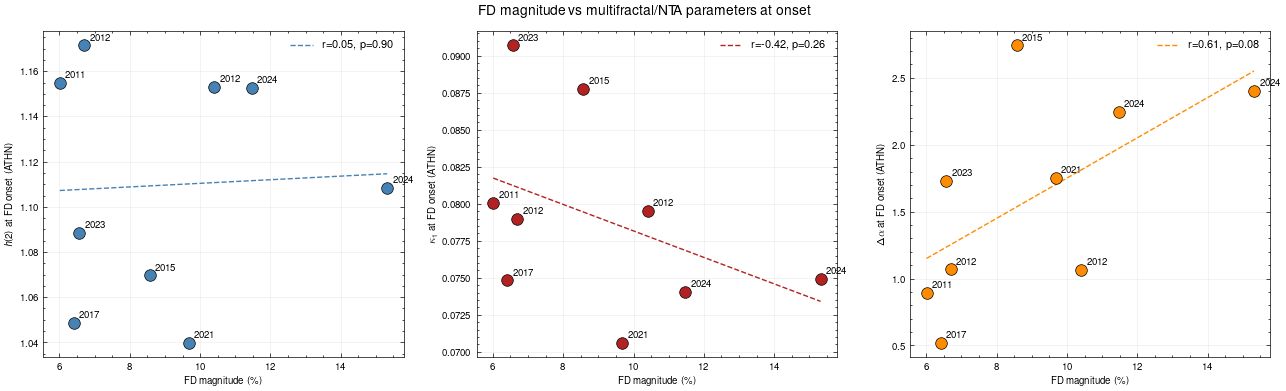

Saved: Figures/Fig10a_FD_Magnitude_Scatter.pdf

All figures saved in Figures/


In [15]:
# Background: windows NOT within 90 days of any FD
def is_near_fd(date, fd_list, margin=90):
    return any(abs((date - fd).days) <= margin for fd in fd_list)

bg_mask    = ~combined_ATHN.index.map(lambda d: is_near_fd(d, fd_dates_list))
background = combined_ATHN[bg_mask]
bg_h2 = background['h2'].mean()
bg_k1 = background['kappa1'].mean()
bg_da = background['delta_alpha'].mean()
print(f'Background ({np.sum(bg_mask)} windows): h2={bg_h2:.4f}  kappa1={bg_k1:.4f}  DeltaAlpha={bg_da:.4f}')

# Pattern check table
print(f'\n{"Date":12s} {"Mag%":>6s} {"h2":>7s} {"h2>bg":>6s} {"k1":>7s} {"k1<bg":>8s} {"DeltaAlpha":>10s} {"da<bg":>8s} {"Both h2 and k1":>8s}')
print('-' * 100)
n_h2 = n_k1 = n_da = n_both = n_three = 0
for date, row in df_fd_params.iterrows():
    h2_ok = row['ATHN_h2'] > bg_h2
    k1_ok = row['ATHN_kappa1'] < bg_k1
    da_ok = row['ATHN_da'] < bg_da
    both  = h2_ok and k1_ok
    three  = h2_ok and k1_ok and da_ok
    if h2_ok: n_h2 += 1
    if k1_ok: n_k1 += 1
    if da_ok: n_da += 1
    if both:  n_both += 1
    if three: n_three +=1
    print(f'{str(date.date()):12s} {row["magnitude"]:6.2f} '
          f'{row["ATHN_h2"]:7.4f} {"YES" if h2_ok else "NO":>6s} '
          f'{row["ATHN_kappa1"]:7.4f} {"YES" if k1_ok else "NO":>8.4s} '
          f'{row["ATHN_da"]:10.4f} {"YES" if da_ok else "NO":>8.4s} '
          f'{"YES" if both else "NO":20.4s}')

N = len(df_fd_params)
print(f'\nh2>bg: {n_h2}/{N} | k1<bg: {n_k1}/{N} | Both: {n_both}/{N}')
print('\nBinomial tests (H1: better than chance, p0=0.5):')
for label, k in [('h2', n_h2), ('kappa1', n_k1), ('Both', n_both)]:
    res = binomtest(k, N, p=0.5, alternative='greater')
    sig = '***' if res.pvalue<0.001 else ('**' if res.pvalue<0.01
          else ('*' if res.pvalue<0.05 else 'ns'))
    print(f'  {label:8s}: {k}/{N}  p={res.pvalue:.4f}  {sig}')

# Mann-Whitney U tests
print('\nMann-Whitney U tests (FD vs background, one-sided):')
tests = [
    ('h2 ATHN',    df_fd_params['ATHN_h2'].dropna().values,
                   background['h2'].values, 'greater'),
    ('kappa1 ATHN', df_fd_params['ATHN_kappa1'].dropna().values,
                   background['kappa1'].values, 'less'),
    ('da JUNG',    df_fd_params['JUNG_da'].dropna().values,
                   combined_JUNG['delta_alpha'][bg_mask[:len(combined_JUNG)]].dropna().values, 'less'),
]
print(f'{"Param":12s} {"FD mean":>9s} {"BG mean":>9s} {"p-value":>10s}')
for nm, fd_arr, bg_arr, alt in tests:
    if len(fd_arr) < 3: continue
    _, p = stats.mannwhitneyu(fd_arr, bg_arr, alternative=alt)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f'{nm:12s} {fd_arr.mean():9.4f} {bg_arr.mean():9.4f} {p:10.4e} {sig}')

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [
    ('ATHN_h2',    '$h(2)$ at FD onset (ATHN)',      'steelblue'),
    ('ATHN_kappa1', r'$\kappa_1$ at FD onset (ATHN)', 'firebrick'),
    ('ATHN_da',    r'$\Delta\alpha$ at FD onset (ATHN)', 'darkorange'),
]
for ax, (ycol, ylabel, color) in zip(axes, pairs):
    x = df_fd_params['magnitude'].values
    y = df_fd_params[ycol].values
    mask = ~np.isnan(y)
    xm, ym = x[mask], y[mask]
    ax.scatter(xm, ym, color=color, s=70, zorder=3, edgecolors='k', lw=0.5)
    for xi, yi, dt in zip(xm, ym, df_fd_params.index[mask]):
        ax.annotate(str(dt.year), (xi, yi),
                    textcoords='offset points', xytext=(4,4), fontsize=7)
    if len(xm) >= 4:
        slope, intercept, r, p, _ = stats.linregress(xm, ym)
        xf = np.linspace(xm.min(), xm.max(), 100)
        ax.plot(xf, slope*xf+intercept, '--', color=color, lw=1.0,
                label=f'r={r:.2f}, p={p:.2f}')
        ax.legend(fontsize=8)
    ax.set_xlabel('FD magnitude (\\%)'); ax.set_ylabel(ylabel); ax.grid(alpha=0.2)
plt.suptitle('FD magnitude vs multifractal/NTA parameters at onset', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/Fig10_FD_Magnitude_Scatter.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig10a_FD_Magnitude_Scatter.pdf')
print('\nAll figures saved in Figures/')


Background (3670 windows): h2=1.0528  kappa1=0.0820  DeltaAlpha=1.3590

Date           Mag%      h2  h2>bg      k1    k1<bg DeltaAlpha    da<bg Both h2 and k1
----------------------------------------------------------------------------------------------------
2011-10-24     6.01  1.1548    YES  0.0800      YES     0.8926      YES YES                 
2012-03-08    10.40  1.1532    YES  0.0795      YES     1.0630      YES YES                 
2012-07-14     6.70  1.1714    YES  0.0790      YES     1.0680      YES YES                 
2015-06-22     8.57  1.0696    YES  0.0878       NO     2.7424       NO NO                  
2017-09-07     6.41  1.0486     NO  0.0748      YES     0.5215      YES NO                  
2021-11-03     9.68  1.0399     NO  0.0706      YES     1.7521       NO NO                  
2023-04-23     6.57  1.0884    YES  0.0907       NO     1.7329       NO NO                  
2024-03-24    11.47  1.1525    YES  0.0741      YES     2.2470       NO YES              

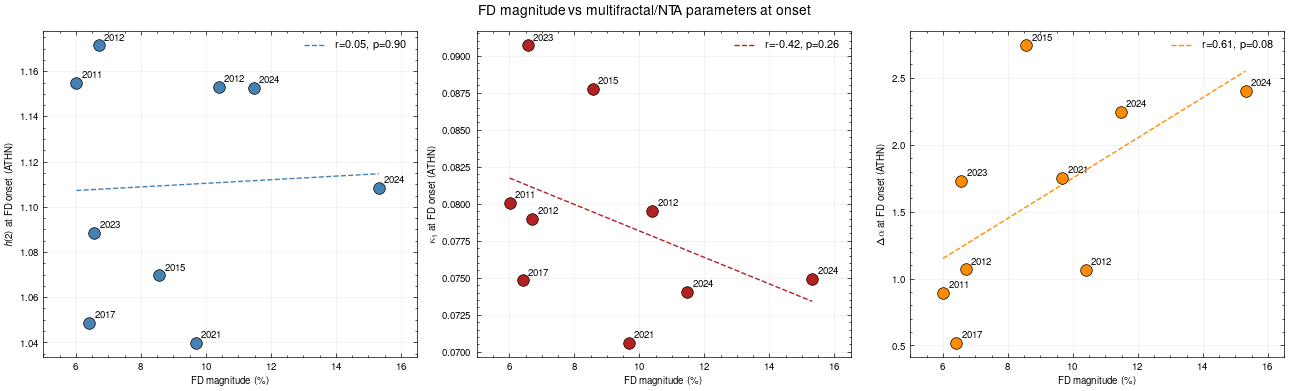

Saved: Figures/Fig10a_FD_Magnitude_Scatter.pdf

All figures saved in Figures/


In [16]:
# Background: windows NOT within 90 days of any FD
def is_near_fd(date, fd_list, margin=90):
    return any(abs((date - fd).days) <= margin for fd in fd_list)

bg_mask    = ~combined_ATHN.index.map(lambda d: is_near_fd(d, fd_dates_list))
background = combined_ATHN[bg_mask]
bg_h2 = background['h2'].mean()
bg_k1 = background['kappa1'].mean()
bg_da = background['delta_alpha'].mean()
print(f'Background ({np.sum(bg_mask)} windows): h2={bg_h2:.4f}  kappa1={bg_k1:.4f}  DeltaAlpha={bg_da:.4f}')

# Pattern check table
print(f'\n{"Date":12s} {"Mag%":>6s} {"h2":>7s} {"h2>bg":>6s} {"k1":>7s} {"k1<bg":>8s} {"DeltaAlpha":>10s} {"da<bg":>8s} {"Both h2 and k1":>8s}')
print('-' * 100)
n_h2 = n_k1 = n_da = n_both = n_three = 0
for date, row in df_fd_params.iterrows():
    h2_ok = row['ATHN_h2'] > bg_h2
    k1_ok = row['ATHN_kappa1'] < bg_k1
    da_ok = row['ATHN_da'] < bg_da
    both  = h2_ok and k1_ok
    three  = h2_ok and k1_ok and da_ok
    if h2_ok: n_h2 += 1
    if k1_ok: n_k1 += 1
    if da_ok: n_da += 1
    if both:  n_both += 1
    if three: n_three +=1
    print(f'{str(date.date()):12s} {row["magnitude"]:6.2f} '
          f'{row["ATHN_h2"]:7.4f} {"YES" if h2_ok else "NO":>6s} '
          f'{row["ATHN_kappa1"]:7.4f} {"YES" if k1_ok else "NO":>8.4s} '
          f'{row["ATHN_da"]:10.4f} {"YES" if da_ok else "NO":>8.4s} '
          f'{"YES" if both else "NO":20.4s}')

N = len(df_fd_params)
print(f'\nh2>bg: {n_h2}/{N} | k1<bg: {n_k1}/{N} | Both: {n_both}/{N}')
print('\nBinomial tests (H1: better than chance, p0=0.5):')
for label, k in [('h2', n_h2), ('kappa1', n_k1), ('Both', n_both)]:
    res = binomtest(k, N, p=0.5, alternative='greater')
    sig = '***' if res.pvalue<0.001 else ('**' if res.pvalue<0.01
          else ('*' if res.pvalue<0.05 else 'ns'))
    print(f'  {label:8s}: {k}/{N}  p={res.pvalue:.4f}  {sig}')

# Mann-Whitney U tests
print('\nMann-Whitney U tests (FD vs background, one-sided):')
tests = [
    ('h2 ATHN',    df_fd_params['ATHN_h2'].dropna().values,
                   background['h2'].values, 'greater'),
    ('kappa1 ATHN', df_fd_params['ATHN_kappa1'].dropna().values,
                   background['kappa1'].values, 'less'),
    ('da ATHN',    df_fd_params['ATHN_da'].dropna().values,
                   combined_JUNG['delta_alpha'][bg_mask[:len(combined_JUNG)]].dropna().values, 'less'),
]
print(f'{"Param":12s} {"FD mean":>9s} {"BG mean":>9s} {"p-value":>10s}')
for nm, fd_arr, bg_arr, alt in tests:
    if len(fd_arr) < 3: continue
    _, p = stats.mannwhitneyu(fd_arr, bg_arr, alternative=alt)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f'{nm:12s} {fd_arr.mean():9.4f} {bg_arr.mean():9.4f} {p:10.4e} {sig}')

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [
    ('ATHN_h2',    '$h(2)$ at FD onset (ATHN)',      'steelblue'),
    ('ATHN_kappa1', r'$\kappa_1$ at FD onset (ATHN)', 'firebrick'),
    ('ATHN_da',    r'$\Delta\alpha$ at FD onset (ATHN)', 'darkorange'),
]
for ax, (ycol, ylabel, color) in zip(axes, pairs):
    x = df_fd_params['magnitude'].values
    y = df_fd_params[ycol].values
    mask = ~np.isnan(y)
    xm, ym = x[mask], y[mask]
    ax.scatter(xm, ym, color=color, s=70, zorder=3, edgecolors='k', lw=0.5)
    for xi, yi, dt in zip(xm, ym, df_fd_params.index[mask]):
        ax.annotate(str(dt.year), (xi, yi),
                    textcoords='offset points', xytext=(4,4), fontsize=7)
    if len(xm) >= 4:
        slope, intercept, r, p, _ = stats.linregress(xm, ym)
        xf = np.linspace(xm.min(), xm.max(), 100)
        ax.plot(xf, slope*xf+intercept, '--', color=color, lw=1.0,
                label=f'r={r:.2f}, p={p:.2f}')
        ax.legend(fontsize=8)
    ax.set_xlim(5,16.5)
    ax.set_xlabel('FD magnitude (\\%)'); ax.set_ylabel(ylabel); ax.grid(alpha=0.2)
plt.suptitle('FD magnitude vs multifractal/NTA parameters at onset', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/Fig10a_FD_Magnitude_Scatter.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig10a_FD_Magnitude_Scatter.pdf')
print('\nAll figures saved in Figures/')


Background (3670 windows): h2=1.0655  kappa1=0.0800  DeltaAlpha=0.6133

Date           Mag%      h2  h2>bg      k1    k1<bg DeltaAlpha    da<bg Both h2 and k1
----------------------------------------------------------------------------------------------------
2011-10-24     6.01  1.1625    YES  0.0829       NO     0.7965       NO NO                  
2012-03-08    10.40  1.1603    YES  0.0851       NO     0.7586       NO NO                  
2012-07-14     6.70  1.1584    YES  0.0819       NO     0.7118       NO NO                  
2015-06-22     8.57  1.1704    YES  0.0896       NO     1.7350       NO NO                  
2017-09-07     6.41  0.9889     NO  0.0879       NO     0.5530      YES NO                  
2021-11-03     9.68  1.0437     NO  0.0708      YES     0.5838      YES NO                  
2023-04-23     6.57  1.0843    YES  0.0717      YES     0.6486       NO YES                 
2024-03-24    11.47  1.1550    YES  0.0810       NO     0.6560       NO NO               

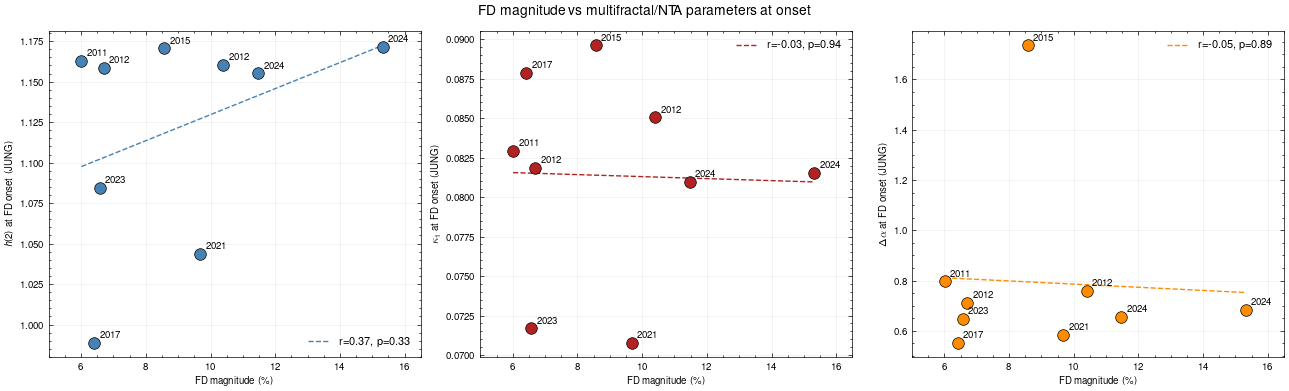

Saved: Figures/Fig10b_FD_Magnitude_Scatter.pdf

All figures saved in Figures/


In [17]:
# Background: windows NOT within 90 days of any FD
def is_near_fd(date, fd_list, margin=90):
    return any(abs((date - fd).days) <= margin for fd in fd_list)

bg_mask    = ~combined_JUNG.index.map(lambda d: is_near_fd(d, fd_dates_list))
background = combined_JUNG[bg_mask]
bg_h2 = background['h2'].mean()
bg_k1 = background['kappa1'].mean()
bg_da = background['delta_alpha'].mean()
print(f'Background ({np.sum(bg_mask)} windows): h2={bg_h2:.4f}  kappa1={bg_k1:.4f}  DeltaAlpha={bg_da:.4f}')

# Pattern check table
print(f'\n{"Date":12s} {"Mag%":>6s} {"h2":>7s} {"h2>bg":>6s} {"k1":>7s} {"k1<bg":>8s} {"DeltaAlpha":>10s} {"da<bg":>8s} {"Both h2 and k1":>8s}')
print('-' * 100)
n_h2 = n_k1 = n_da = n_both = n_three = 0
for date, row in df_fd_params.iterrows():
    h2_ok = row['JUNG_h2'] > bg_h2
    k1_ok = row['JUNG_kappa1'] < bg_k1
    da_ok = row['JUNG_da'] < bg_da
    both  = h2_ok and k1_ok
    three  = h2_ok and k1_ok and da_ok
    if h2_ok: n_h2 += 1
    if k1_ok: n_k1 += 1
    if da_ok: n_da += 1
    if both:  n_both += 1
    if three: n_three +=1
    print(f'{str(date.date()):12s} {row["magnitude"]:6.2f} '
          f'{row["JUNG_h2"]:7.4f} {"YES" if h2_ok else "NO":>6s} '
          f'{row["JUNG_kappa1"]:7.4f} {"YES" if k1_ok else "NO":>8.4s} '
          f'{row["JUNG_da"]:10.4f} {"YES" if da_ok else "NO":>8.4s} '
          f'{"YES" if both else "NO":20.4s}')

N = len(df_fd_params)
print(f'\nh2>bg: {n_h2}/{N} | k1<bg: {n_k1}/{N} | Both: {n_both}/{N}')
print('\nBinomial tests (H1: better than chance, p0=0.5):')
for label, k in [('h2', n_h2), ('kappa1', n_k1), ('Both', n_both)]:
    res = binomtest(k, N, p=0.5, alternative='greater')
    sig = '***' if res.pvalue<0.001 else ('**' if res.pvalue<0.01
          else ('*' if res.pvalue<0.05 else 'ns'))
    print(f'  {label:8s}: {k}/{N}  p={res.pvalue:.4f}  {sig}')

# Mann-Whitney U tests
print('\nMann-Whitney U tests (FD vs background, one-sided):')
tests = [
    ('h2 JUNG',    df_fd_params['JUNG_h2'].dropna().values,
                   background['h2'].values, 'greater'),
    ('kappa1 JUNG', df_fd_params['JUNG_kappa1'].dropna().values,
                   background['kappa1'].values, 'less'),
    ('da JUNG',    df_fd_params['JUNG_da'].dropna().values,
                   combined_JUNG['delta_alpha'][bg_mask[:len(combined_JUNG)]].dropna().values, 'less'),
]
print(f'{"Param":12s} {"FD mean":>9s} {"BG mean":>9s} {"p-value":>10s}')
for nm, fd_arr, bg_arr, alt in tests:
    if len(fd_arr) < 3: continue
    _, p = stats.mannwhitneyu(fd_arr, bg_arr, alternative=alt)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f'{nm:12s} {fd_arr.mean():9.4f} {bg_arr.mean():9.4f} {p:10.4e} {sig}')

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [
    ('JUNG_h2',    '$h(2)$ at FD onset (JUNG)',      'steelblue'),
    ('JUNG_kappa1', r'$\kappa_1$ at FD onset (JUNG)', 'firebrick'),
    ('JUNG_da',    r'$\Delta\alpha$ at FD onset (JUNG)', 'darkorange'),
]
for ax, (ycol, ylabel, color) in zip(axes, pairs):
    x = df_fd_params['magnitude'].values
    y = df_fd_params[ycol].values
    mask = ~np.isnan(y)
    xm, ym = x[mask], y[mask]
    ax.scatter(xm, ym, color=color, s=70, zorder=3, edgecolors='k', lw=0.5)
    for xi, yi, dt in zip(xm, ym, df_fd_params.index[mask]):
        ax.annotate(str(dt.year), (xi, yi),
                    textcoords='offset points', xytext=(4,4), fontsize=7)
    if len(xm) >= 4:
        slope, intercept, r, p, _ = stats.linregress(xm, ym)
        xf = np.linspace(xm.min(), xm.max(), 100)
        ax.plot(xf, slope*xf+intercept, '--', color=color, lw=1.0,
                label=f'r={r:.2f}, p={p:.2f}')
        ax.legend(fontsize=8)
    ax.set_xlim(5,16.5)
    ax.set_xlabel('FD magnitude (\\%)'); ax.set_ylabel(ylabel); ax.grid(alpha=0.2)
plt.suptitle('FD magnitude vs multifractal/NTA parameters at onset', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/Fig10b_FD_Magnitude_Scatter.pdf', dpi=300, bbox_inches='tight')
plt.show(); print('Saved: Figures/Fig10b_FD_Magnitude_Scatter.pdf')
print('\nAll figures saved in Figures/')
